# Exp7.3 — Training Strategy Decomposition

Analysis-only notebook. Primary metric: **final LIF test balanced accuracy** after every training strategy is normalized to the same $\beta=0.5$ LIF spike-count deployment.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd()
if not (repo / 'notebooks').exists():
    repo = repo.parent
base = repo / 'notebooks' / 'artifacts' / 'experiment_7_3_training_strategy_decomposition' / 'training_strategy_decomposition_v1'
manifest = json.loads((base / 'manifest.json').read_text())
runs = pd.read_csv(base / 'method_runs.csv')
summary = pd.read_csv(base / 'method_summary.csv')
two_stage = pd.read_csv(base / 'two_stage_matrix_summary.csv')
contrasts = pd.read_csv(base / 'contrast_summary.csv')
manifest


{'architecture': '234x234',
 'ce_gain': 1.0,
 'checkpoint_rule': 'native validation BA primary, native objective loss tiebreak',
 'counts': {'e2e_runs': 12,
  'final_method_seed_rows': 36,
  'stage2_backbone_caches': 6,
  'stage2_runs': 24},
 'e2e_methods': ['A1_e2e_linear_tsce',
  'A2_e2e_linear_wcce',
  'A3_e2e_lif_tsce',
  'A4_e2e_lif_wcce'],
 'experiment_id': 'experiment_7_3_training_strategy_decomposition',
 'final_deployment_contract': 'Every method is re-evaluated through the same beta=0.5, threshold=0.5, cap=1 LIF spike-count simulator.',
 'hypothesis_method': 'B2_tsbackbone_linear_wcce',
 'lif_beta': 0.5,
 'output_cap': 1,
 'primary_metric': 'final_lif_test_ba',
 'protocol_version': 'training_strategy_decomposition_v1',
 'regularization': 'task_only',
 'seeds': [11, 23, 37],
 'shifts': [[2, 3, 4], [2, 3, 4]],
 'stage2_contract': 'Stage 1 uses Linear TSCE/WCCE to train L1/L2, then discards W; Stage 2 freezes L1/L2 and retrains a fresh W with paired initialization/order.',
 'thr

## 1. All methods under common final LIF deployment

In [2]:
method_order = manifest['e2e_methods'] + manifest['two_stage_methods']
view = summary.set_index('method').loc[method_order].reset_index()
cols = [
    'method', 'group', 'backbone_objective', 'w_objective', 'w_train_readout',
    'analog_test_ba_mean', 'final_lif_test_ba_mean', 'final_lif_test_ba_std',
    'analog_to_lif_gap_pp_mean', 'l2_wholecount_probe_test_ba_mean',
    'l2_fixed250_probe_test_ba_mean'
]
view[cols]


,method,group,backbone_objective,w_objective,w_train_readout,analog_test_ba_mean,final_lif_test_ba_mean,final_lif_test_ba_std,analog_to_lif_gap_pp_mean,l2_wholecount_probe_test_ba_mean,l2_fixed250_probe_test_ba_mean
0,A1_e2e_linear_tsce,e2e,tsce,tsce,linear,0.471928,0.458620,0.032782,1.330776,0.596121,0.581999
1,A2_e2e_linear_wcce,e2e,wcce,wcce,linear,0.564502,0.524684,0.037378,3.981736,0.586273,0.587253
2,A3_e2e_lif_tsce,e2e,tsce,tsce,lif,0.396816,0.387958,0.020680,0.885781,0.481034,0.536906
3,A4_e2e_lif_wcce,e2e,wcce,wcce,lif,0.462968,0.463645,0.041503,-0.067710,0.544754,0.560853
4,B1_tsbackbone_linear_tsce,two_stage,tsce,tsce,linear,0.466340,0.436928,0.034130,2.941156,0.596121,0.581999
5,B2_tsbackbone_linear_wcce,two_stage,tsce,wcce,linear,0.511073,0.497301,0.050861,1.377234,0.596121,0.581999
6,B3_tsbackbone_lif_tsce,two_stage,tsce,tsce,lif,0.408432,0.399778,0.031981,0.865431,0.596121,0.581999
7,B4_tsbackbone_lif_wcce,two_stage,tsce,wcce,lif,0.491800,0.484551,0.050278,0.724969,0.596121,0.581999
8,B5_wcbackbone_linear_tsce,two_stage,wcce,tsce,linear,0.491666,0.479236,0.048618,1.242993,0.586273,0.587253
9,B6_wcbackbone_linear_wcce,two_stage,wcce,wcce,linear,0.552707,0.522762,0.012987,2.994459,0.586273,0.587253


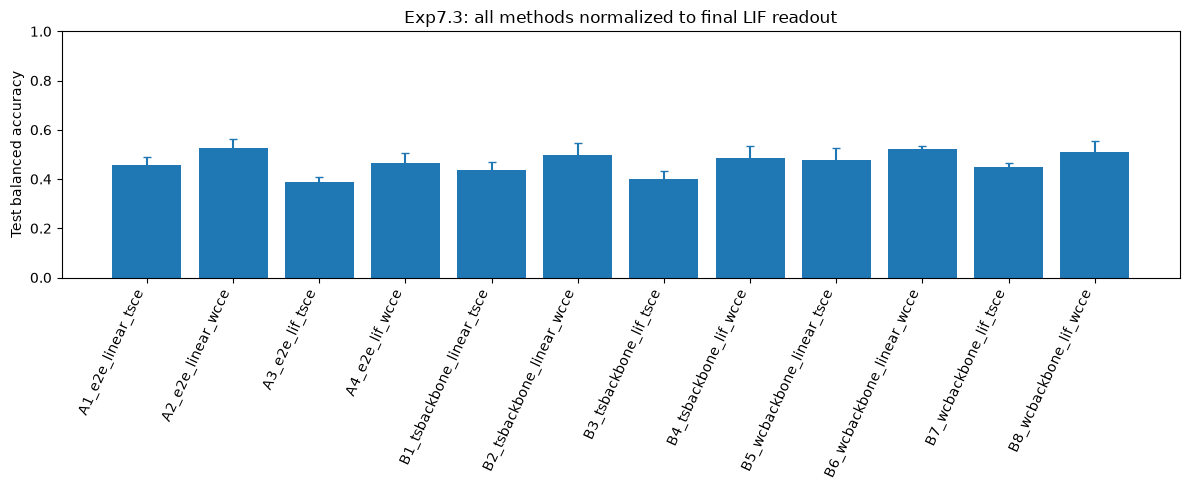

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(view))
ax.bar(x, view['final_lif_test_ba_mean'])
ax.errorbar(x, view['final_lif_test_ba_mean'], yerr=view['final_lif_test_ba_std'], fmt='none', capsize=3)
ax.set_xticks(x, view['method'], rotation=65, ha='right')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp7.3: all methods normalized to final LIF readout')
ax.set_ylim(0, 1)
fig.tight_layout()


## 2. Two-stage factorial matrix

Rows isolate Stage-1 backbone objective; columns isolate Stage-2 W objective and W-training readout.

In [4]:
matrix = two_stage.pivot_table(
    index='backbone_objective',
    columns=['w_train_readout', 'w_objective'],
    values='final_lif_test_ba_mean',
)
matrix


w_train_readout          lif              linear          
w_objective             tsce      wcce      tsce      wcce
backbone_objective                                        
tsce                0.399778  0.484551  0.436928  0.497301
wcce                0.449354  0.508652  0.479236  0.522762

## 3. Representation quality vs final LIF accuracy

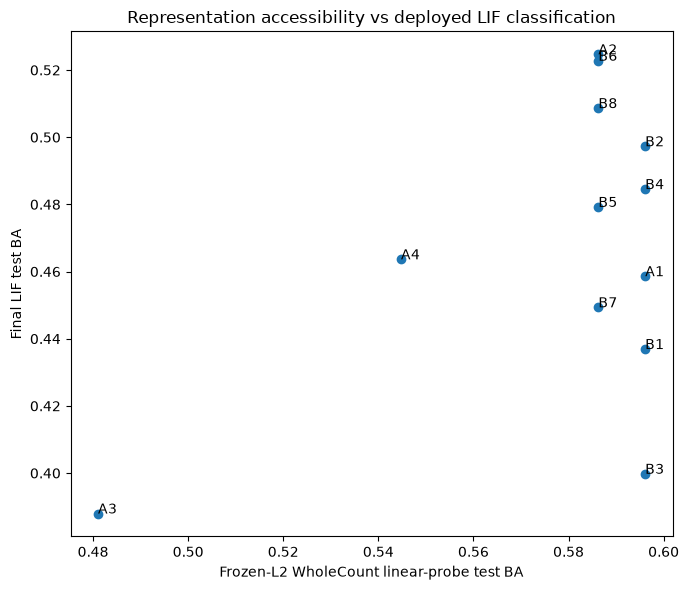

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(view['l2_wholecount_probe_test_ba_mean'], view['final_lif_test_ba_mean'])
for _, row in view.iterrows():
    ax.annotate(row['method'].split('_')[0], (row['l2_wholecount_probe_test_ba_mean'], row['final_lif_test_ba_mean']))
ax.set_xlabel('Frozen-L2 WholeCount linear-probe test BA')
ax.set_ylabel('Final LIF test BA')
ax.set_title('Representation accessibility vs deployed LIF classification')
fig.tight_layout()


## 4. Pre-registered key contrasts

Positive delta means the left method has higher final-LIF test BA.

In [6]:
contrasts[['contrast', 'left_method', 'right_method', 'final_lif_delta_pp_mean', 'final_lif_delta_pp_std']]


,contrast,left_method,right_method,final_lif_delta_pp_mean,final_lif_delta_pp_std
0,A1_minus_A3_e2e_tsce_linear_vs_lif,A1_e2e_linear_tsce,A3_e2e_lif_tsce,7.066151,4.980143
1,A2_minus_A4_e2e_wcce_linear_vs_lif,A2_e2e_linear_wcce,A4_e2e_lif_wcce,6.103919,7.375131
2,B2_minus_B6_ts_vs_wc_backbone,B2_tsbackbone_linear_wcce,B6_wcbackbone_linear_wcce,-2.546088,5.656317
3,B2_minus_B1_wcce_vs_tsce_W,B2_tsbackbone_linear_wcce,B1_tsbackbone_linear_tsce,6.037296,5.233828
4,B2_minus_B4_linear_vs_lif_W_training,B2_tsbackbone_linear_wcce,B4_tsbackbone_lif_wcce,1.275044,5.438981
5,B2_minus_A1_two_stage_vs_e2e_linear_tsce,B2_tsbackbone_linear_wcce,A1_e2e_linear_tsce,3.868123,3.915271
6,B2_minus_A2_two_stage_vs_e2e_linear_wcce,B2_tsbackbone_linear_wcce,A2_e2e_linear_wcce,-2.738326,8.769655
7,B2_minus_A3_two_stage_vs_e2e_lif_tsce,B2_tsbackbone_linear_wcce,A3_e2e_lif_tsce,10.934274,7.144691
8,B2_minus_A4_two_stage_vs_e2e_lif_wcce,B2_tsbackbone_linear_wcce,A4_e2e_lif_wcce,3.365593,2.465812
